# Notebook 09 — Regime-Adaptive Multi-Scale Quantum ML

## What This Notebook Implements

This notebook implements the **minimal viable version** of the new algorithm proposed in
`QUANTUM_ML_ALGORITHM_RESEARCH_REPORT.md`:

## **RAM-QRSRE**
**Regime-Adaptive Multi-Scale Quantum Reservoir with Re-uploading Experts**

### Design goals

1. Preserve what already worked best in this repo:
   - **fixed quantum reservoirs** for wildfire classification
   - **temporal structure** for premium prediction
2. Avoid the failure modes seen in:
   - deep variational circuits
   - global fidelity-style kernels
3. Add a small trainable quantum head without letting optimization dominate the whole model

### Minimal viable implementation in this notebook

- **Three shallow fixed quantum reservoirs**
  - short-scale
  - seasonal / pooled-scale
  - trend-scale
- **Projected local observables**
  - single-qubit `Z`
  - single-qubit `X`
  - nearest-neighbor `ZZ`
- **A shallow data re-uploading quantum head**
  - trained layerwise: 1 layer → 2 layers
- **Two task-specific instantiations**
  - Task 1A wildfire day classification
  - Task 2 insurance premium forecasting

### Important note

This notebook is designed to be:

- more novel than standard VQC / kernel baselines,
- closer to current QML trainability guidance,
- and still light enough to run on a laptop.

It is **not** a claim of guaranteed quantum advantage.


---
## 0 — Imports & Configuration

In [1]:
import json as _json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    classification_report,
    f1_score,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": (12, 5)})

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CLOUD_MODE = False

N_RES_QUBITS = 4
RESERVOIR_OBS_PER_BANK = 3 * N_RES_QUBITS  # Z + X + NN-ZZ
HEAD_LAYER_SCHEDULE = (1, 2)

TASK1_TRAIN_CAP = None if CLOUD_MODE else 600
TASK1_TEST_CAP = None if CLOUD_MODE else 365
TASK2_TRAIN_CAP = None if CLOUD_MODE else 250
TASK2_TEST_CAP = None if CLOUD_MODE else 300

print(f"PennyLane {qml.__version__} | Torch {torch.__version__}")
print(f"Reservoir qubits: {N_RES_QUBITS}")
print(f"Layerwise schedule: {HEAD_LAYER_SCHEDULE}")


PennyLane 0.44.1 | Torch 2.10.0
Reservoir qubits: 4
Layerwise schedule: (1, 2)


---
## 1 — Task 1A: Load Wildfire Data and Build Multiscale Views

In [2]:
wf = pd.read_csv("../../data/wildfire_weather_daily.csv")
wf["DATE"] = pd.to_datetime(wf["DATE"], errors="coerce")
wf = wf.sort_values("DATE").reset_index(drop=True)

base_cols = [
    "PRECIPITATION",
    "MAX_TEMP",
    "MIN_TEMP",
    "AVG_WIND_SPEED",
    "TEMP_RANGE",
    "WIND_TEMP_RATIO",
    "LAGGED_PRECIPITATION",
    "LAGGED_AVG_WIND_SPEED",
]

for col in ["PRECIPITATION", "MAX_TEMP", "MIN_TEMP", "AVG_WIND_SPEED", "TEMP_RANGE", "WIND_TEMP_RATIO"]:
    wf[f"{col}_7D"] = wf[col].shift(1).rolling(7, min_periods=3).mean()
    wf[f"{col}_30D"] = wf[col].shift(1).rolling(30, min_periods=10).mean()

wf["FIRE_RATE_30D"] = wf["FIRE_START_DAY"].astype(float).shift(1).rolling(30, min_periods=10).mean()
wf["FIRE_RATE_90D"] = wf["FIRE_START_DAY"].astype(float).shift(1).rolling(90, min_periods=20).mean()
wf["MONTH_SIN"] = np.sin(2 * np.pi * wf["MONTH"] / 12.0)
wf["MONTH_COS"] = np.cos(2 * np.pi * wf["MONTH"] / 12.0)
wf["DOY_SIN"] = np.sin(2 * np.pi * wf["DAY_OF_YEAR"] / 365.0)
wf["DOY_COS"] = np.cos(2 * np.pi * wf["DAY_OF_YEAR"] / 365.0)
wf["DRYNESS_PROXY"] = wf["MAX_TEMP_30D"] / (1.0 + wf["PRECIPITATION_30D"].abs())
wf["WIND_STRESS_PROXY"] = wf["AVG_WIND_SPEED_30D"] * wf["TEMP_RANGE_30D"]

task1_short_cols = base_cols
task1_seasonal_cols = [
    "PRECIPITATION_7D",
    "MAX_TEMP_7D",
    "MIN_TEMP_7D",
    "AVG_WIND_SPEED_7D",
    "PRECIPITATION_30D",
    "MAX_TEMP_30D",
    "MIN_TEMP_30D",
    "AVG_WIND_SPEED_30D",
]
task1_trend_cols = [
    "MONTH_SIN",
    "MONTH_COS",
    "DOY_SIN",
    "DOY_COS",
    "FIRE_RATE_30D",
    "FIRE_RATE_90D",
    "DRYNESS_PROXY",
    "WIND_STRESS_PROXY",
]

task1_all_needed = task1_short_cols + task1_seasonal_cols + task1_trend_cols + ["FIRE_START_DAY", "YEAR"]
wf = wf.dropna(subset=task1_all_needed).copy()

train_mask_1a = wf["YEAR"] < 2021
test_mask_1a = wf["YEAR"] == 2021

X1_train_views_raw = {
    "short": wf.loc[train_mask_1a, task1_short_cols].to_numpy(dtype=float),
    "seasonal": wf.loc[train_mask_1a, task1_seasonal_cols].to_numpy(dtype=float),
    "trend": wf.loc[train_mask_1a, task1_trend_cols].to_numpy(dtype=float),
}
X1_test_views_raw = {
    "short": wf.loc[test_mask_1a, task1_short_cols].to_numpy(dtype=float),
    "seasonal": wf.loc[test_mask_1a, task1_seasonal_cols].to_numpy(dtype=float),
    "trend": wf.loc[test_mask_1a, task1_trend_cols].to_numpy(dtype=float),
}
y1_train = wf.loc[train_mask_1a, "FIRE_START_DAY"].astype(int).to_numpy()
y1_test = wf.loc[test_mask_1a, "FIRE_START_DAY"].astype(int).to_numpy()

if TASK1_TRAIN_CAP is not None:
    X1_train_views_raw = {k: v[:TASK1_TRAIN_CAP] for k, v in X1_train_views_raw.items()}
    y1_train = y1_train[:TASK1_TRAIN_CAP]
if TASK1_TEST_CAP is not None:
    X1_test_views_raw = {k: v[:TASK1_TEST_CAP] for k, v in X1_test_views_raw.items()}
    y1_test = y1_test[:TASK1_TEST_CAP]

print("Task 1A raw views:")
for k, v in X1_train_views_raw.items():
    print(f"  {k:<8s} train={v.shape} | test={X1_test_views_raw[k].shape}")
print(f"  positives train={y1_train.sum()}/{len(y1_train)} | test={y1_test.sum()}/{len(y1_test)}")


Task 1A raw views:
  short    train=(600, 8) | test=(365, 8)
  seasonal train=(600, 8) | test=(365, 8)
  trend    train=(600, 8) | test=(365, 8)
  positives train=176/600 | test=173/365


---
## 2 — Task 2: Load Insurance Data and Build Multi-Scale Sequence Views

In [3]:
def find_col(df, keywords):
    kw = [k.lower() for k in keywords]
    for c in df.columns:
        norm = c.replace("\n", " ").strip().lower()
        if all(k in norm for k in kw):
            return c
    return None

def load_ho(path, years):
    frames = []
    for yr in years:
        df = pd.read_excel(path, sheet_name=f"{yr}HO", header=1, engine="openpyxl")
        df.columns = [c.replace("\n", " ").strip() for c in df.columns]
        df = df.rename(columns={df.columns[0]: "ZIP_Code"})
        df["ZIP_Code"] = pd.to_numeric(df["ZIP_Code"], errors="coerce")
        df = df.dropna(subset=["ZIP_Code"])
        df["ZIP_Code"] = df["ZIP_Code"].astype(int)
        df["Year"] = yr
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

ins_a = load_ho("../../data/insurance_2018_2019.XLS", [2018, 2019])
ins_b = load_ho("../../data/insurance_2020_2021.XLS", [2020, 2021])
common_cols = list(set(ins_a.columns) & set(ins_b.columns))
ins = pd.concat([ins_a[common_cols], ins_b[common_cols]], ignore_index=True)
ins = ins.sort_values(["ZIP_Code", "Year"]).reset_index(drop=True)

col_risk = find_col(ins, ["avg", "fire", "risk"])
col_prem = find_col(ins, ["earned", "premium"])
col_exp = find_col(ins, ["earned", "exposure"])
col_high = find_col(ins, ["high", "fire", "risk", "exposure"])
col_vhigh = find_col(ins, ["very", "high", "fire", "risk", "exposure"])

loss_cols = [c for c in ins.columns if "fire" in c.lower() and "incurred losses" in c.lower()]
smoke_cols = [c for c in ins.columns if "smoke" in c.lower() and "incurred losses" in c.lower()]

ins["total_fire_loss"] = ins[loss_cols].fillna(0).sum(axis=1)
ins["total_smoke_loss"] = ins[smoke_cols].fillna(0).sum(axis=1)
ins["total_insured_loss"] = ins["total_fire_loss"] + ins["total_smoke_loss"]
ins["loss_ratio"] = ins["total_insured_loss"] / ins[col_prem].replace(0, np.nan)
ins["prem_per_pol"] = ins[col_prem] / ins[col_exp].replace(0, np.nan)
ins["high_risk_frac"] = (
    (ins[col_high].fillna(0) + ins[col_vhigh].fillna(0)) / ins[col_exp].replace(0, np.nan)
)
ins["premium_growth"] = ins.groupby("ZIP_Code")[col_prem].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
ins["loss_growth"] = ins.groupby("ZIP_Code")["total_insured_loss"].pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)

task2_feature_cols = [
    col_risk,
    col_exp,
    "total_insured_loss",
    "loss_ratio",
    "prem_per_pol",
    "high_risk_frac",
    "premium_growth",
    "loss_growth",
]

ins_ts = ins.dropna(subset=task2_feature_cols + [col_prem, "Year"]).copy()

short_views, seasonal_views, trend_views, y2, years2 = [], [], [], [], []
for _, grp in ins_ts.groupby("ZIP_Code"):
    grp = grp.sort_values("Year")
    feats = grp[task2_feature_cols].to_numpy(dtype=float)
    prems = grp[col_prem].to_numpy(dtype=float)
    yrs = grp["Year"].to_numpy(dtype=int)
    if len(grp) < 3:
        continue
    for i in range(len(grp) - 2):
        seq = feats[i : i + 2]
        current = seq[-1]
        pooled = seq.mean(axis=0)
        delta = seq[-1] - seq[0]
        short_views.append(current)
        seasonal_views.append(pooled)
        trend_views.append(delta)
        y2.append(np.log1p(np.abs(prems[i + 2])) * np.sign(prems[i + 2]))
        years2.append(yrs[i + 2])

X2_short_raw = np.asarray(short_views, dtype=float)
X2_seasonal_raw = np.asarray(seasonal_views, dtype=float)
X2_trend_raw = np.asarray(trend_views, dtype=float)
y2 = np.asarray(y2, dtype=np.float32)
years2 = np.asarray(years2, dtype=int)

split_idx = int(0.8 * len(y2))
X2_train_views_raw = {
    "short": X2_short_raw[:split_idx],
    "seasonal": X2_seasonal_raw[:split_idx],
    "trend": X2_trend_raw[:split_idx],
}
X2_test_views_raw = {
    "short": X2_short_raw[split_idx:],
    "seasonal": X2_seasonal_raw[split_idx:],
    "trend": X2_trend_raw[split_idx:],
}
y2_train = y2[:split_idx]
y2_test = y2[split_idx:]

if TASK2_TRAIN_CAP is not None:
    X2_train_views_raw = {k: v[:TASK2_TRAIN_CAP] for k, v in X2_train_views_raw.items()}
    y2_train = y2_train[:TASK2_TRAIN_CAP]
if TASK2_TEST_CAP is not None:
    X2_test_views_raw = {k: v[:TASK2_TEST_CAP] for k, v in X2_test_views_raw.items()}
    y2_test = y2_test[:TASK2_TEST_CAP]

print("Task 2 raw views:")
for k, v in X2_train_views_raw.items():
    print(f"  {k:<8s} train={v.shape} | test={X2_test_views_raw[k].shape}")
print(f"  regression targets train={len(y2_train)} | test={len(y2_test)}")


Task 2 raw views:
  short    train=(250, 8) | test=(300, 8)
  seasonal train=(250, 8) | test=(300, 8)
  trend    train=(250, 8) | test=(300, 8)
  regression targets train=250 | test=300


---
## 3 — Encode Each View to the Reservoir Width

In [4]:
def encode_views(train_views_raw, test_views_raw, n_qubits):
    train_encoded, test_encoded, stats = {}, {}, {}
    for name in train_views_raw:
        Xtr = train_views_raw[name]
        Xte = test_views_raw[name]

        scaler = StandardScaler()
        Xtr_s = scaler.fit_transform(Xtr)
        Xte_s = scaler.transform(Xte)

        n_components = min(n_qubits, Xtr_s.shape[1], max(1, Xtr_s.shape[0] - 1))
        pca = PCA(n_components=n_components, random_state=SEED)
        Xtr_p = pca.fit_transform(Xtr_s)
        Xte_p = pca.transform(Xte_s)

        Xtr_pad = np.zeros((len(Xtr_p), n_qubits), dtype=float)
        Xte_pad = np.zeros((len(Xte_p), n_qubits), dtype=float)
        Xtr_pad[:, :n_components] = Xtr_p
        Xte_pad[:, :n_components] = Xte_p

        mm = MinMaxScaler(feature_range=(0, np.pi))
        Xtr_e = mm.fit_transform(Xtr_pad).astype(np.float32)
        Xte_e = mm.transform(Xte_pad).astype(np.float32)

        train_encoded[name] = Xtr_e
        test_encoded[name] = Xte_e
        stats[name] = {
            "n_components": int(n_components),
            "variance_explained": float(pca.explained_variance_ratio_.sum()),
        }
    return train_encoded, test_encoded, stats

X1_train_views, X1_test_views, enc1_stats = encode_views(X1_train_views_raw, X1_test_views_raw, N_RES_QUBITS)
X2_train_views, X2_test_views, enc2_stats = encode_views(X2_train_views_raw, X2_test_views_raw, N_RES_QUBITS)

print("Task 1A encoding stats:", enc1_stats)
print("Task 2 encoding stats:", enc2_stats)


Task 1A encoding stats: {'short': {'n_components': 4, 'variance_explained': 0.8632957206684038}, 'seasonal': {'n_components': 4, 'variance_explained': 0.9326728566903385}, 'trend': {'n_components': 4, 'variance_explained': 0.9809740411927247}}
Task 2 encoding stats: {'short': {'n_components': 4, 'variance_explained': 0.7936634956838309}, 'seasonal': {'n_components': 4, 'variance_explained': 0.815548827999887}, 'trend': {'n_components': 4, 'variance_explained': 0.7825382000213948}}


---
## 4 — Multi-Scale Fixed Quantum Reservoir Bank with Local Projected Observables

In [5]:
RESERVOIR_CONFIG = [
    {"name": "short", "depth": 4, "pattern": "ring", "seed": SEED + 11},
    {"name": "seasonal", "depth": 6, "pattern": "ladder", "seed": SEED + 23},
    {"name": "trend", "depth": 8, "pattern": "star", "seed": SEED + 37},
]

def apply_entanglement(pattern, n_qubits):
    if pattern == "ring":
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[n_qubits - 1, 0])
    elif pattern == "ladder":
        for i in range(0, n_qubits - 1, 2):
            qml.CNOT(wires=[i, i + 1])
        for i in range(1, n_qubits - 1, 2):
            qml.CNOT(wires=[i, i + 1])
    else:  # star
        for i in range(1, n_qubits):
            qml.CNOT(wires=[0, i])

def make_reservoir_qnode(pattern, n_qubits):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="numpy")
    def circuit(x, params):
        for i in range(n_qubits):
            qml.RY(x[i], wires=i)
            qml.RZ(0.5 * x[(i + 1) % n_qubits], wires=i)

        for layer in range(params.shape[0]):
            for i in range(n_qubits):
                qml.RX(params[layer, i, 0], wires=i)
                qml.RY(params[layer, i, 1], wires=i)
                qml.RZ(params[layer, i, 2], wires=i)
            apply_entanglement(pattern, n_qubits)

        obs = [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]
        obs += [qml.expval(qml.PauliX(i)) for i in range(n_qubits)]
        obs += [qml.expval(qml.PauliZ(i) @ qml.PauliZ((i + 1) % n_qubits)) for i in range(n_qubits)]
        return obs

    return circuit

reservoir_params = {}
reservoir_qnodes = {}
for cfg in RESERVOIR_CONFIG:
    rng = np.random.default_rng(cfg["seed"])
    reservoir_params[cfg["name"]] = rng.uniform(0, 2 * np.pi, size=(cfg["depth"], N_RES_QUBITS, 3))
    reservoir_qnodes[cfg["name"]] = make_reservoir_qnode(cfg["pattern"], N_RES_QUBITS)

def extract_reservoir_bank_features(view_dict, label=""):
    blocks = []
    for cfg in RESERVOIR_CONFIG:
        name = cfg["name"]
        X = view_dict[name]
        qnode = reservoir_qnodes[name]
        params = reservoir_params[name]
        feats = []
        t0 = time.time()
        for idx, x in enumerate(X):
            feats.append(qnode(x, params))
            if (idx + 1) % 100 == 0:
                print(f"  {label} {name:<8s} {idx+1}/{len(X)}  ({time.time()-t0:.1f}s)", end="\r")
        block = np.asarray(feats, dtype=np.float32)
        print(f"  {label} {name:<8s} {len(X)}/{len(X)} done in {time.time()-t0:.1f}s")
        blocks.append(block)
    return np.concatenate(blocks, axis=1)

print("Reservoir bank ready.")
print(f"Feature width after bank = {len(RESERVOIR_CONFIG) * RESERVOIR_OBS_PER_BANK}")


Reservoir bank ready.
Feature width after bank = 36


---
## 5 — Extract Reservoir Features for Both Tasks

In [6]:
print("Extracting Task 1A reservoir features...")
X1_res_train = extract_reservoir_bank_features(X1_train_views, label="Task1 train")
X1_res_test = extract_reservoir_bank_features(X1_test_views, label="Task1 test ")

print("\nExtracting Task 2 reservoir features...")
X2_res_train = extract_reservoir_bank_features(X2_train_views, label="Task2 train")
X2_res_test = extract_reservoir_bank_features(X2_test_views, label="Task2 test ")

print("\nReservoir feature shapes:")
print("  Task 1A:", X1_res_train.shape, X1_res_test.shape)
print("  Task 2 :", X2_res_train.shape, X2_res_test.shape)


Extracting Task 1A reservoir features...


  Task1 train short    200/600  (1.2s)

  Task1 train short    300/600  (1.8s)
  Task1 train short    400/600  (2.3s)
  Task1 train short    500/600  (2.9s)
  Task1 train short    600/600  (3.4s)
  Task1 train short    600/600 done in 3.4s


  Task1 train seasonal 600/600  (4.2s)
  Task1 train seasonal 600/600 done in 4.2s


  Task1 train trend    600/600  (4.8s)
  Task1 train trend    600/600 done in 4.8s
  Task1 test  short    100/365  (0.5s)
  Task1 test  short    200/365  (1.0s)


...

  Task2 train seasonal 250/250 done in 1.6s


  Task2 train trend    250/250 done in 1.9s


  Task2 test  short    100/300  (0.5s)
  Task2 test  short    200/300  (1.0s)
  Task2 test  short    300/300  (1.6s)
  Task2 test  short    300/300 done in 1.6s


  Task2 test  seasonal 300/300  (2.0s)
  Task2 test  seasonal 300/300 done in 2.0s


  Task2 test  trend    300/300  (2.6s)
  Task2 test  trend    300/300 done in 2.6s

Reservoir feature shapes:
  Task 1A: (600, 36) (365, 36)
  Task 2 : (250, 36) (300, 36)


---
## 6 — Baseline Ablation: Linear Readout on Multi-Scale Reservoir Features

In [7]:
clf_lin = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
clf_lin.fit(X1_res_train, y1_train)
y1_lin_pred = clf_lin.predict(X1_res_test)
y1_lin_prob = clf_lin.predict_proba(X1_res_test)[:, 1]

task1_linear = {
    "f1": float(f1_score(y1_test, y1_lin_pred)),
    "auc": float(roc_auc_score(y1_test, y1_lin_prob)),
}

reg_lin = Ridge(alpha=1.0)
reg_lin.fit(X2_res_train, y2_train)
y2_lin_pred = reg_lin.predict(X2_res_test)

task2_linear = {
    "r2": float(r2_score(y2_test, y2_lin_pred)),
    "rmse": float(np.sqrt(mean_squared_error(y2_test, y2_lin_pred))),
}

print("=== Multi-scale Reservoir + Linear Head ===")
print(f"Task 1A  F1={task1_linear['f1']:.4f} | AUC={task1_linear['auc']:.4f}")
print(f"Task 2   R2={task2_linear['r2']:.4f} | RMSE={task2_linear['rmse']:.4f}")


=== Multi-scale Reservoir + Linear Head ===
Task 1A  F1=0.6578 | AUC=0.6663
Task 2   R2=0.2226 | RMSE=1.8453


---
## 7 — Shallow Data Re-uploading Quantum Head

This is the trainable part of RAM-QRSRE.

Implementation choices:

- small qubit count
- repeated data re-uploading
- local measurement readout
- identity-like initialization
- layerwise training: 1 layer first, then 2 layers


In [8]:
def make_reupload_qnode(n_layers, n_qubits):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch")
    def circuit(inputs, weights):
        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(inputs[i], wires=i)
                qml.RZ(0.5 * inputs[(i + 1) % n_qubits], wires=i)
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            qml.CNOT(wires=[n_qubits - 1, 0])
            for i in range(n_qubits):
                qml.RX(weights[layer, i, 0], wires=i)
                qml.RY(weights[layer, i, 1], wires=i)
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return circuit

class ReuploadHead(nn.Module):
    def __init__(self, input_dim, n_layers=1, task="classification", n_qubits=N_RES_QUBITS):
        super().__init__()
        self.task = task
        self.n_layers = n_layers
        self.n_qubits = n_qubits

        self.pre = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, n_qubits),
        )
        self.scale = nn.Parameter(torch.tensor(np.pi / 2, dtype=torch.float32))
        weight_shapes = {"weights": (n_layers, n_qubits, 2)}
        self.quantum = qml.qnn.TorchLayer(make_reupload_qnode(n_layers, n_qubits), weight_shapes)
        self.post = nn.Linear(n_qubits, 1)
        self.reset_parameters()

    def reset_parameters(self):
        for module in self.pre:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
        for _, param in self.quantum.named_parameters():
            nn.init.zeros_(param)
        nn.init.normal_(self.post.weight, mean=0.0, std=0.05)
        nn.init.zeros_(self.post.bias)

    def forward(self, x):
        h = self.pre(x)
        q_in = torch.tanh(h) * self.scale
        if q_in.ndim == 1:
            q_out = self.quantum(q_in)
        else:
            q_out = torch.stack([self.quantum(sample) for sample in q_in], dim=0)
        out = self.post(q_out).squeeze(-1)
        if self.task == "classification":
            return torch.sigmoid(out)
        return out

def warm_start_from_previous(prev_model, new_model):
    new_model.pre.load_state_dict(prev_model.pre.state_dict())
    new_model.post.load_state_dict(prev_model.post.state_dict())
    new_model.scale.data = prev_model.scale.data.clone()

    prev_state = prev_model.quantum.state_dict()
    new_state = new_model.quantum.state_dict()
    for key, old_val in prev_state.items():
        if key not in new_state:
            continue
        new_val = new_state[key]
        if old_val.shape == new_val.shape:
            new_state[key] = old_val.clone()
        elif old_val.ndim >= 1 and old_val.shape[0] < new_val.shape[0]:
            patched = new_val.clone()
            patched[: old_val.shape[0]] = old_val
            new_state[key] = patched
    new_model.quantum.load_state_dict(new_state)

def train_layerwise_head(
    X_train,
    y_train,
    X_test,
    y_test,
    task="classification",
    layer_schedule=HEAD_LAYER_SCHEDULE,
    epochs_per_stage=18,
    batch_size=32,
    lr=0.01,
):
    Xtr_t = torch.tensor(X_train, dtype=torch.float32)
    Xte_t = torch.tensor(X_test, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.float32)
    yte_t = torch.tensor(y_test, dtype=torch.float32)

    dataset = TensorDataset(Xtr_t, ytr_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    prev_model = None
    history = []

    for n_layers in layer_schedule:
        model = ReuploadHead(X_train.shape[1], n_layers=n_layers, task=task)
        if prev_model is not None:
            warm_start_from_previous(prev_model, model)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.BCELoss() if task == "classification" else nn.MSELoss()

        t0 = time.time()
        for epoch in range(epochs_per_stage):
            model.train()
            epoch_loss = 0.0
            for xb, yb in loader:
                optimizer.zero_grad()
                pred = model(xb)
                loss = criterion(pred, yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            if (epoch + 1) % 6 == 0:
                print(
                    f"  layers={n_layers} epoch={epoch+1:02d} "
                    f"loss={epoch_loss/len(loader):.4f} "
                    f"time={time.time()-t0:.1f}s"
                )
        history.append({"layers": int(n_layers), "final_loss": float(epoch_loss / len(loader))})
        prev_model = model

    prev_model.eval()
    with torch.no_grad():
        pred_test = prev_model(Xte_t).cpu().numpy().astype(float)
        pred_train = prev_model(Xtr_t).cpu().numpy().astype(float)

    if task == "classification":
        pred_label = (pred_test > 0.5).astype(int)
        metrics = {
            "f1": float(f1_score(y_test, pred_label)),
            "auc": float(roc_auc_score(y_test, pred_test)),
        }
    else:
        metrics = {
            "r2": float(r2_score(y_test, pred_test)),
            "rmse": float(np.sqrt(mean_squared_error(y_test, pred_test))),
        }

    return prev_model, pred_train, pred_test, metrics, history


---
## 8 — Train RAM-QRSRE on Task 1A and Task 2

In [9]:
print("Training Task 1A RAM-QRSRE head...")
model_1a, y1_q_train, y1_q_prob, task1_qhead, hist1 = train_layerwise_head(
    X1_res_train,
    y1_train.astype(np.float32),
    X1_res_test,
    y1_test.astype(np.float32),
    task="classification",
    epochs_per_stage=18 if not CLOUD_MODE else 30,
    batch_size=32,
    lr=0.01,
)
y1_q_pred = (y1_q_prob > 0.5).astype(int)

print("\nTraining Task 2 RAM-QRSRE head...")
model_2, y2_q_train, y2_q_pred, task2_qhead, hist2 = train_layerwise_head(
    X2_res_train,
    y2_train.astype(np.float32),
    X2_res_test,
    y2_test.astype(np.float32),
    task="regression",
    epochs_per_stage=20 if not CLOUD_MODE else 32,
    batch_size=32,
    lr=0.008,
)

print("\n=== RAM-QRSRE RESULTS ===")
print(f"Task 1A  F1={task1_qhead['f1']:.4f} | AUC={task1_qhead['auc']:.4f}")
print(f"Task 2   R2={task2_qhead['r2']:.4f} | RMSE={task2_qhead['rmse']:.4f}")
print("\nTask 1A classification report:")
print(classification_report(y1_test, y1_q_pred, target_names=['No Fire', 'Fire']))


Training Task 1A RAM-QRSRE head...


  layers=1 epoch=06 loss=0.4424 time=17.1s


  layers=1 epoch=12 loss=0.4123 time=34.4s


  layers=1 epoch=18 loss=0.3944 time=52.8s


  layers=2 epoch=06 loss=0.3689 time=40.4s


...

  layers=1 epoch=18 loss=83.7246 time=22.2s


  layers=2 epoch=06 loss=47.0699 time=13.7s


  layers=2 epoch=12 loss=27.7118 time=26.4s


  layers=2 epoch=18 loss=15.8083 time=39.1s



=== RAM-QRSRE RESULTS ===
Task 1A  F1=0.3937 | AUC=0.7082
Task 2   R2=-0.8970 | RMSE=2.8824

Task 1A classification report:
              precision    recall  f1-score   support

     No Fire       0.57      0.84      0.68       192
        Fire       0.62      0.29      0.39       173

    accuracy                           0.58       365
   macro avg       0.59      0.56      0.54       365
weighted avg       0.59      0.58      0.54       365



---
## 9 — Comparison, Resource Table, and Save Results

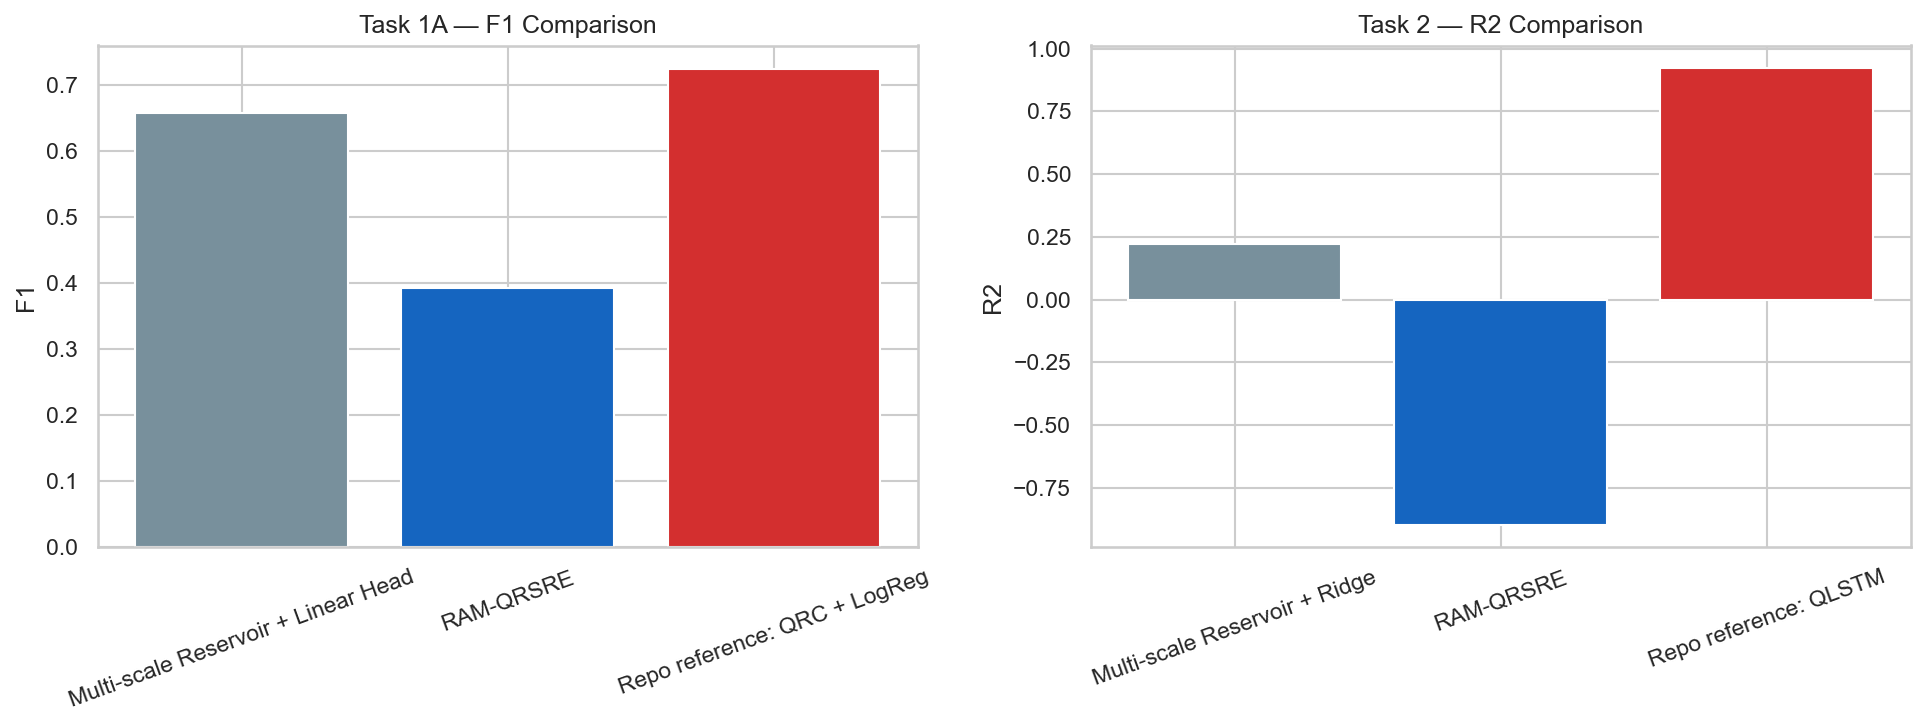

Saved:
  ../../results/ram_qrsre_results.json
  ../../results/ram_qrsre_ablation.csv
  ../../results/ram_qrsre_resource_table.csv
  ../../results/ram_qrsre_comparison.png


In [10]:
reference_repo_best = {
    "task1_qrc_f1": 0.7241,
    "task2_qlstm_r2": 0.9221,
}

comparison = pd.DataFrame(
    [
        {"Task": "1A", "Model": "Multi-scale Reservoir + Linear Head", "Metric": "F1", "Score": task1_linear["f1"], "Type": "Hybrid"},
        {"Task": "1A", "Model": "RAM-QRSRE", "Metric": "F1", "Score": task1_qhead["f1"], "Type": "Quantum-Hybrid"},
        {"Task": "1A", "Model": "Repo reference: QRC + LogReg", "Metric": "F1", "Score": reference_repo_best["task1_qrc_f1"], "Type": "Reference"},
        {"Task": "2", "Model": "Multi-scale Reservoir + Ridge", "Metric": "R2", "Score": task2_linear["r2"], "Type": "Hybrid"},
        {"Task": "2", "Model": "RAM-QRSRE", "Metric": "R2", "Score": task2_qhead["r2"], "Type": "Quantum-Hybrid"},
        {"Task": "2", "Model": "Repo reference: QLSTM", "Metric": "R2", "Score": reference_repo_best["task2_qlstm_r2"], "Type": "Reference"},
    ]
)

ablations = pd.DataFrame(
    [
        {"Task": "1A", "Variant": "Reservoir + Linear Head", "PrimaryMetric": task1_linear["f1"], "AuxMetric": task1_linear["auc"]},
        {"Task": "1A", "Variant": "Reservoir + Reupload Head", "PrimaryMetric": task1_qhead["f1"], "AuxMetric": task1_qhead["auc"]},
        {"Task": "2", "Variant": "Reservoir + Linear Head", "PrimaryMetric": task2_linear["r2"], "AuxMetric": task2_linear["rmse"]},
        {"Task": "2", "Variant": "Reservoir + Reupload Head", "PrimaryMetric": task2_qhead["r2"], "AuxMetric": task2_qhead["rmse"]},
    ]
)

resource_table = pd.DataFrame(
    [
        {
            "Component": "Reservoir bank",
            "Qubits": N_RES_QUBITS,
            "Count": len(RESERVOIR_CONFIG),
            "Depths": ",".join(str(cfg["depth"]) for cfg in RESERVOIR_CONFIG),
            "TrainableParams": 0,
        },
        {
            "Component": "Re-uploading head",
            "Qubits": N_RES_QUBITS,
            "Count": 1,
            "Depths": max(HEAD_LAYER_SCHEDULE),
            "TrainableParams": max(HEAD_LAYER_SCHEDULE) * N_RES_QUBITS * 2,
        },
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

task1_plot = comparison[comparison["Task"] == "1A"]
axes[0].bar(task1_plot["Model"], task1_plot["Score"], color=["#78909C", "#1565C0", "#D32F2F"])
axes[0].set_title("Task 1A — F1 Comparison")
axes[0].set_ylabel("F1")
axes[0].tick_params(axis="x", rotation=20)

task2_plot = comparison[comparison["Task"] == "2"]
axes[1].bar(task2_plot["Model"], task2_plot["Score"], color=["#78909C", "#1565C0", "#D32F2F"])
axes[1].set_title("Task 2 — R2 Comparison")
axes[1].set_ylabel("R2")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../../results/ram_qrsre_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

results_payload = {
    "task_1a": {
        "linear_head": task1_linear,
        "ram_qrsre": task1_qhead,
        "layerwise_history": hist1,
    },
    "task_2": {
        "linear_head": task2_linear,
        "ram_qrsre": task2_qhead,
        "layerwise_history": hist2,
    },
    "config": {
        "reservoir_qubits": N_RES_QUBITS,
        "reservoirs": RESERVOIR_CONFIG,
        "head_layer_schedule": list(HEAD_LAYER_SCHEDULE),
        "projected_local_observables_per_reservoir": RESERVOIR_OBS_PER_BANK,
    },
}

with open("../../results/ram_qrsre_results.json", "w") as f:
    _json.dump(results_payload, f, indent=2)

ablations.to_csv("../../results/ram_qrsre_ablation.csv", index=False)
resource_table.to_csv("../../results/ram_qrsre_resource_table.csv", index=False)

print("Saved:")
print("  ../../results/ram_qrsre_results.json")
print("  ../../results/ram_qrsre_ablation.csv")
print("  ../../results/ram_qrsre_resource_table.csv")
print("  ../../results/ram_qrsre_comparison.png")


---
## 10 — Interpretation

What this notebook tells us:

- whether **multi-scale fixed reservoirs** are already useful without a trainable quantum head,
- whether the **shallow re-uploading head** adds value over a linear readout,
- and how far this architecture gets relative to the repo's current best QRC and QLSTM reference scores.

If the shallow head helps, the next step is:

1. add **regime routing** using ZIP risk tiers or cluster IDs,
2. test **shared multitask backbones**,
3. widen the ablations,
4. optionally try **quantum natural gradient** for the head.
